In [2]:
import pandas as pd
import numpy as np

# Load fusion architecture data
fusion_arch = pd.read_csv("fusion_workload_projects_architecture.csv")

# Work on a copy and keep all original columns
fa = fusion_arch.copy()

# Choose an effective nodes column
if "Nodes" in fa.columns:
    fa["Nodes_eff"] = pd.to_numeric(fa["Nodes"], errors="coerce")
elif "Average Nodes" in fa.columns:
    fa["Nodes_eff"] = pd.to_numeric(fa["Average Nodes"], errors="coerce")
else:
    fa["Nodes_eff"] = np.nan

# Convert numeric where present
for c in ["Power_per_Node_kW", "Runtime_h", "Work_Units"]:
    if c in fa.columns:
        fa[c] = pd.to_numeric(fa[c], errors="coerce")

# Derived lines
fa["Power_draw_kW"] = fa["Nodes_eff"] * fa.get("Power_per_Node_kW", np.nan)
fa["Power_draw_MW"] = fa["Power_draw_kW"] / 1000.0
fa["Energy_per_job_kWh"] = fa.get("Runtime_h", np.nan) * fa["Power_draw_kW"]
fa["Science_per_kWh"] = fa.get("Work_Units", np.nan) / fa["Energy_per_job_kWh"]
fa["Cost_per_job_$"] = 0.10 * fa["Energy_per_job_kWh"]
fa["Science_per_$"] = fa.get("Work_Units", np.nan) / fa["Cost_per_job_$"]

# Classify type from Node_Type and Platform text
def classify_type(row):
    s = ""
    if "Node_Type" in fa.columns:
        s += str(row.get("Node_Type", ""))
    if "Platform" in fa.columns:
        s += " " + str(row.get("Platform", ""))
    s = s.lower()
    if "hybrid" in s:
        return "HYBRID"
    if "gpu" in s or "nvidia" in s or "a100" in s or "h100" in s or "mi250" in s:
        return "GPU"
    if "cpu" in s:
        return "CPU"
    return None

fa["Type_norm"] = fa.apply(classify_type, axis=1)

# Keep only CPU, GPU, HYBRID rows
allowed = {"CPU", "GPU", "HYBRID"}
before = len(fa)
fa = fa[fa["Type_norm"].isin(allowed)].copy()
print(f"Kept {len(fa)} of {before} fusion rows that are CPU, GPU, or HYBRID")

# Add size and build eligibility
fa["Size_MW"] = pd.to_numeric(fa.get("Power_draw_MW", np.nan), errors="coerce")
eligible = fa[fa["Size_MW"].notna() & fa.get("Runtime_h").notna()].copy()
ineligible = fa[~fa.index.isin(eligible.index)].copy()
print(f"Eligible tasks {len(eligible)}   Ineligible not scheduled {len(ineligible)}")


Kept 153 of 250 fusion rows that are CPU, GPU, or HYBRID
Eligible tasks 153   Ineligible not scheduled 0


In [3]:
# Build priority from Work_Units percent and Science_per_kWh percent
total_work = pd.to_numeric(eligible.get("Work_Units", np.nan), errors="coerce").sum(skipna=True)
eligible["Work_Units_pct"] = (eligible["Work_Units"] / total_work) if total_work else 0.0

max_spk = pd.to_numeric(eligible.get("Science_per_kWh", np.nan), errors="coerce").max(skipna=True)
eligible["Science_eff_pct"] = (eligible["Science_per_kWh"] / max_spk) if pd.notna(max_spk) and max_spk > 0 else 0.0

w_work = 0.6
w_eff  = 0.4
eligible["Priority"] = w_work * eligible["Work_Units_pct"] + w_eff * eligible["Science_eff_pct"]

# Scheduler parameters
GLOBAL_FUSION_CAP_MW = 4.8

# Add schedule metadata without removing columns
sched = eligible.copy()
sched["Scheduled"] = False
sched["Cycle"] = pd.NA
sched["Bucket"] = pd.NA            # will store CPU, GPU, or HYBRID from Type_norm
sched["MW_used"] = np.nan
sched["Row_ID"] = sched.index      # stable id

schedule_rows = []
cycle_rows = []
cycle = 1

# Simultaneous scheduling across all types by Priority then by Size_MW
while True:
    remaining = sched[~sched["Scheduled"]].copy()
    if remaining.empty:
        break

    cap_rem = GLOBAL_FUSION_CAP_MW
    placed_any = False

    candidates = remaining.sort_values(["Priority", "Size_MW"], ascending=[False, False])
    for rid, row in candidates.iterrows():
        need = row["Size_MW"]
        if pd.isna(need) or pd.isna(row["Runtime_h"]):
            continue
        if need <= cap_rem:
            sched.loc[rid, ["Scheduled", "Cycle", "Bucket", "MW_used"]] = [True, cycle, row["Type_norm"], need]
            cap_rem -= need
            placed_any = True
            schedule_rows.append({
                "Cycle": cycle,
                "Bucket": row["Type_norm"],
                "Row_ID": row["Row_ID"],
                "Workload": row.get("Workload", ""),
                "Project_Name": row.get("Project_Name", ""),
                "Power_draw_MW": row["Size_MW"],
                "Runtime_h": row["Runtime_h"],
                "Priority": row["Priority"]
            })
        if cap_rem <= 0:
            break

    if not placed_any:
        print("No tasks fit under the 4.8 MW cap this cycle. Consider splitting very large tasks.")
        break

    placed_this_cycle = [r for r in schedule_rows if r["Cycle"] == cycle]
    cycle_time = max((r["Runtime_h"] for r in placed_this_cycle), default=0.0)
    used_mw = sum((r["Power_draw_MW"] for r in placed_this_cycle))
    cycle_rows.append({
        "Cycle": cycle,
        "Used_MW": used_mw,
        "Remaining_MW": cap_rem,
        "Cycle_time_h": cycle_time
    })

    cycle += 1

# Build outputs
schedule = pd.DataFrame(schedule_rows)
cycle_summary = pd.DataFrame(cycle_rows)


In [4]:
from zoneinfo import ZoneInfo

# Choose a local start date and time for the schedule
# Example  change this to your desired start
START_DATETIME_LOCAL = "2025-08-15 09:00"
TIMEZONE = "America/Chicago"

# Parse and localize
start_ts = pd.Timestamp(START_DATETIME_LOCAL)
if start_ts.tzinfo is None:
    start_ts = start_ts.tz_localize(ZoneInfo(TIMEZONE))
else:
    start_ts = start_ts.tz_convert(ZoneInfo(TIMEZONE))

# Compute cycle start and end stamps
cycle_summary = cycle_summary.sort_values("Cycle").reset_index(drop=True)
cycle_starts = []
cycle_ends = []
current_start = start_ts

for _, row in cycle_summary.iterrows():
    cycle_starts.append(current_start)
    dur_h = float(row["Cycle_time_h"]) if pd.notna(row["Cycle_time_h"]) else 0.0
    current_end = current_start + pd.to_timedelta(dur_h, unit="h")
    cycle_ends.append(current_end)
    current_start = current_end

cycle_summary["Cycle_Start"] = cycle_starts
cycle_summary["Cycle_End"] = cycle_ends

# Attach start and end to each task
schedule = schedule.merge(
    cycle_summary[["Cycle","Cycle_Start","Cycle_End"]],
    on="Cycle", how="left"
)

schedule["Task_Start"] = schedule["Cycle_Start"]
schedule["Task_End"] = schedule["Task_Start"] + pd.to_timedelta(schedule["Runtime_h"], unit="h")

# Friendly day columns
schedule["Task_Start_Day"] = schedule["Task_Start"].dt.strftime("%Y-%m-%d")
schedule["Task_Start_Weekday"] = schedule["Task_Start"].dt.strftime("%A")

# Add order in cycle and final sort
schedule["Order_in_Cycle"] = schedule.groupby("Cycle").cumcount() + 1
schedule = schedule.sort_values(["Cycle", "Order_in_Cycle"]).reset_index(drop=True)

# Overall start and end for the whole plan
plan_start = schedule["Cycle_Start"].min()
plan_end = cycle_summary["Cycle_End"].max() if len(cycle_summary) else plan_start
print(f"Plan start  {plan_start}")
print(f"Plan end    {plan_end}")


Plan start  2025-08-15 09:00:00-05:00
Plan end    2025-08-17 05:07:36.471478798-05:00


In [5]:
# Full table with schedule metadata for all fusion rows
fa_with_schedule = fa.copy()
fa_with_schedule = fa_with_schedule.merge(
    sched[["Row_ID", "Scheduled", "Cycle", "Bucket", "MW_used"]],
    left_index=True, right_on="Row_ID", how="left"
).drop(columns=["Row_ID"])

# Save CSVs
fa_with_schedule.to_csv("fusion_arch_with_schedule_4p8MW_simultaneous.csv", index=False)
schedule.to_csv("fusion_schedule_cycles_4p8MW_simultaneous.csv", index=False)
cycle_summary.to_csv("fusion_cycle_summary_4p8MW_simultaneous.csv", index=False)

print("Saved fusion_arch_with_schedule_4p8MW_simultaneous.csv")
print("Saved fusion_schedule_cycles_4p8MW_simultaneous.csv")
print("Saved fusion_cycle_summary_4p8MW_simultaneous.csv")


Saved fusion_arch_with_schedule_4p8MW_simultaneous.csv
Saved fusion_schedule_cycles_4p8MW_simultaneous.csv
Saved fusion_cycle_summary_4p8MW_simultaneous.csv


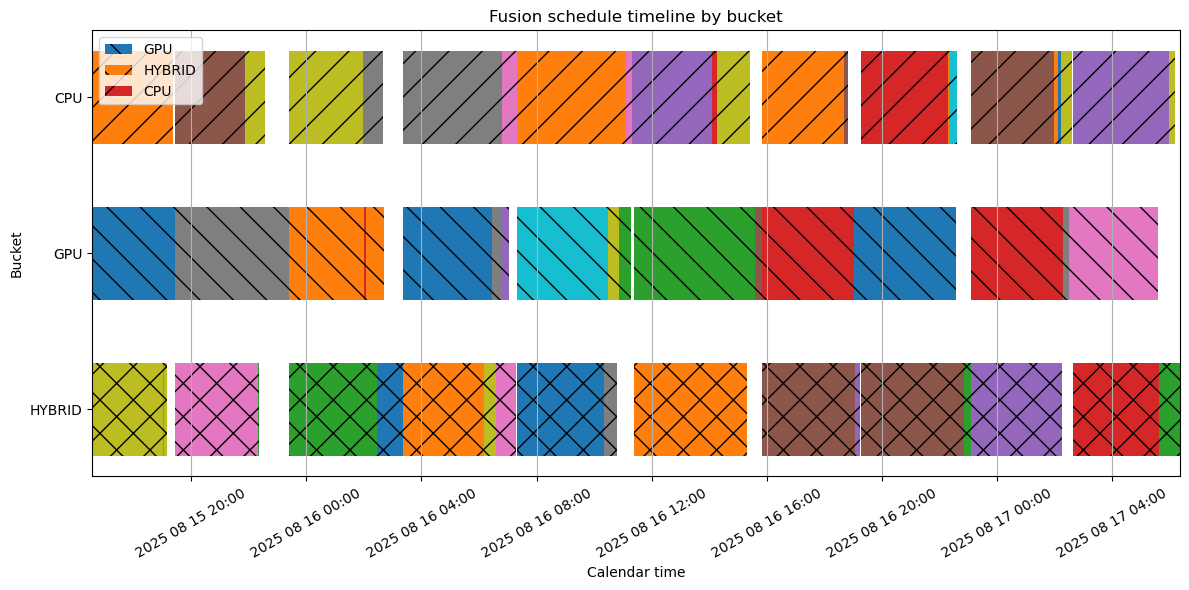

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = schedule.copy().sort_values(["Cycle","Order_in_Cycle"]).reset_index(drop=True)

# Y positions for lanes
lane_map = {"CPU": 3, "GPU": 2, "HYBRID": 1}
df["y"] = df["Bucket"].map(lane_map)

plt.figure(figsize=(12, 6))

# Optional hatches so lanes are easy to tell apart without choosing colors
hatch_map = {"CPU": "/", "GPU": "\\", "HYBRID": "x"}

seen = set()
for _, r in df.iterrows():
    label = r["Bucket"] if r["Bucket"] not in seen else None
    plt.barh(
        y=r["y"],
        width=(r["Task_End"] - r["Task_Start"]),
        left=r["Task_Start"],
        height=0.6,
        align="center",
        label=label,
        hatch=hatch_map.get(r["Bucket"], None)
    )
    seen.add(r["Bucket"])

plt.yticks([1,2,3], ["HYBRID","GPU","CPU"])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y %m %d %H:%M"))
plt.xticks(rotation=30)
plt.xlabel("Calendar time")
plt.ylabel("Bucket")
plt.title("Fusion schedule timeline by bucket")
plt.grid(True, axis="x")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


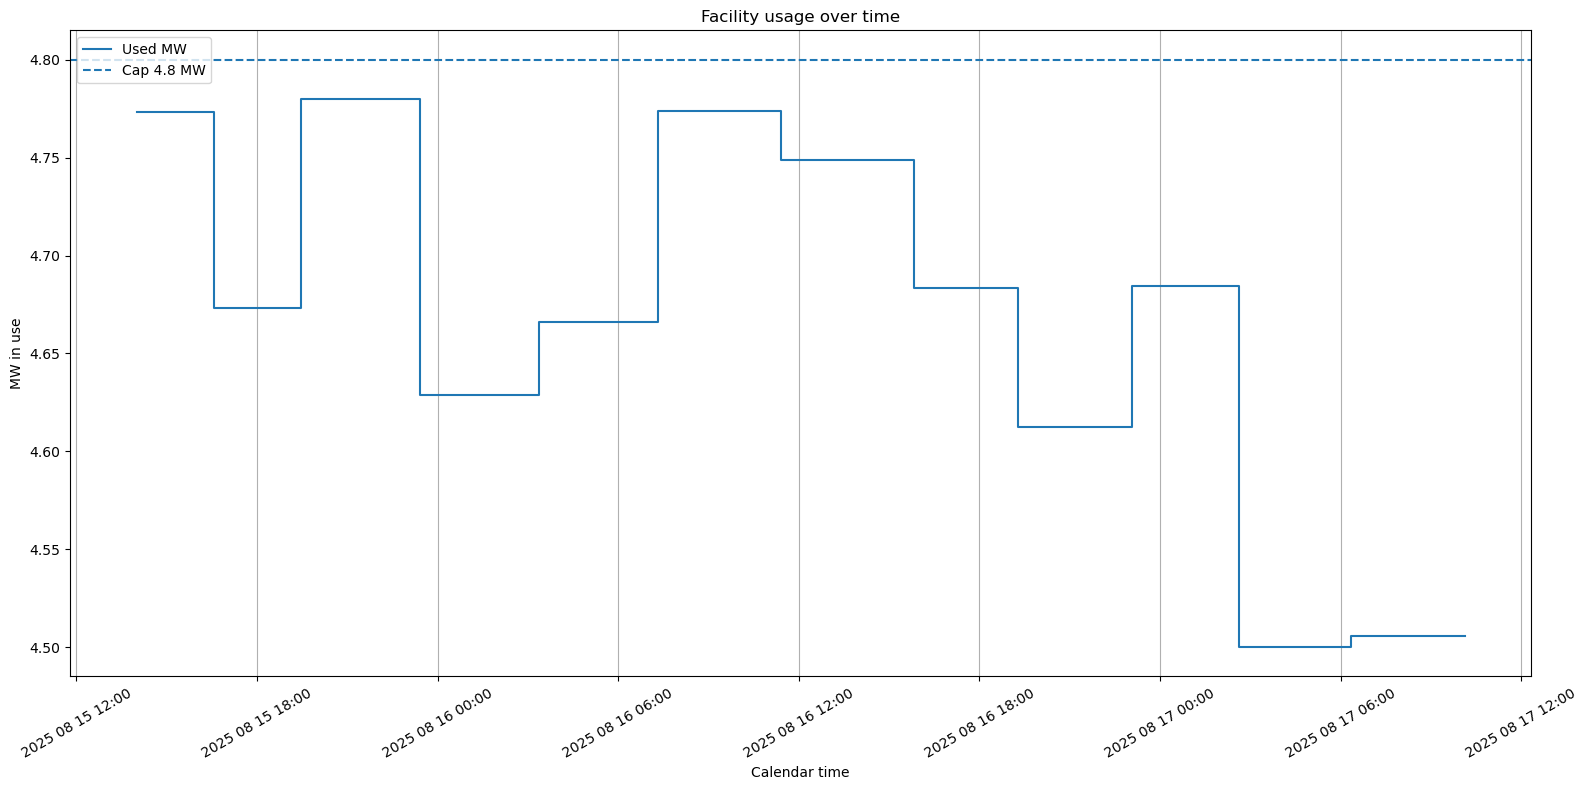

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

cs = cycle_summary.sort_values("Cycle").reset_index(drop=True)

# Build step series
xs = []
ys = []
for _, row in cs.iterrows():
    xs.extend([row["Cycle_Start"], row["Cycle_End"]])
    ys.extend([row["Used_MW"], row["Used_MW"]])

plt.figure(figsize=(16, 8))
plt.step(xs, ys, where="post", label="Used MW")
plt.axhline(y=4.8, linestyle="--", label="Cap 4.8 MW")  # uses default color

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y %m %d %H:%M"))
plt.xticks(rotation=30)
plt.xlabel("Calendar time")
plt.ylabel("MW in use")
plt.title("Facility usage over time")
plt.grid(True, axis="x")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig('my_plot.png')
plt.show()


<Figure size 640x480 with 0 Axes>